# E01:
Tune the hyperparameters of the training to beat my best validation loss of 2.2

In [316]:
import random
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:

BLOCK_SIZE = 4  # context length: how many characters do we take to predict the next one
CHAR_DIM = 4   # demension of character embedding space
INPUT_LAYER_SIZE = BLOCK_SIZE * CHAR_DIM
HIDDEN_LAYER_SIZE = 1600 # hidden layer size
BATCH_SIZE = 256 
N_ITER = 200000

def get_lr(i):
    if i < (N_ITER / 2):
        return 0.1
    return 0.01

# (4, 4, 800, 256, 200'000) -> 2.1586
# (4, 2, 800, 256, 200'000) -> 2.1920
# (4, 4, 400, 256, 200'000) -> 2.1625
# (4, 4, 800, 128, 200'000) -> 2.1847
# (4, 8, 800, 256, 200'000) -> 2.1659
# (3, 8, 400, 256, 200'000) -> 2.1677

# (4, 4, 1600, 256, 200'000) -> 2.1330

In [318]:
# read in all the words
words = open('../../../data/name.txt', 'r').read().splitlines()

In [319]:
# build the vocabulary of characters and mapping to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s : i + 1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i : s for s, i in stoi.items()}

In [320]:
# build the dataset
def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * BLOCK_SIZE
        for ch in w + ".":
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]  # crop and append

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1 : n2])
Xte, Yte = build_dataset(words[n2:])


torch.Size([182625, 4]) torch.Size([182625])
torch.Size([22655, 4]) torch.Size([22655])
torch.Size([22866, 4]) torch.Size([22866])


In [321]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, CHAR_DIM), generator=g)
W1 = torch.randn((INPUT_LAYER_SIZE, HIDDEN_LAYER_SIZE), generator=g)
b1 = torch.randn(HIDDEN_LAYER_SIZE, generator=g)
W2 = torch.randn((HIDDEN_LAYER_SIZE, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True


In [322]:
stepsi, lossi = [], []

In [323]:
for i in range(N_ITER):
    # minibatch construction
    ix = torch.randint(0, Xtr.shape[0], (BATCH_SIZE,))

    # forward pass 
    emb = C[Xtr[ix]]  # (BATCH_SIZE, BLOCK_SIZE, CHAR_DIM)
    h = torch.tanh(emb.view(-1, BLOCK_SIZE * CHAR_DIM) @ W1 + b1)   # (BATCH_SIZE, BLOCK_SIZE * CHAR_DIM)
    logits = h @ W2 + b2    # (BATCH_SIZE, 27)
    loss = F.cross_entropy(logits, Ytr[ix])

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = get_lr(i)
    for p in parameters:
        p.data += -lr * p.grad
    
    # track stats
    stepsi.append(i)
    lossi.append(loss.log10().item())


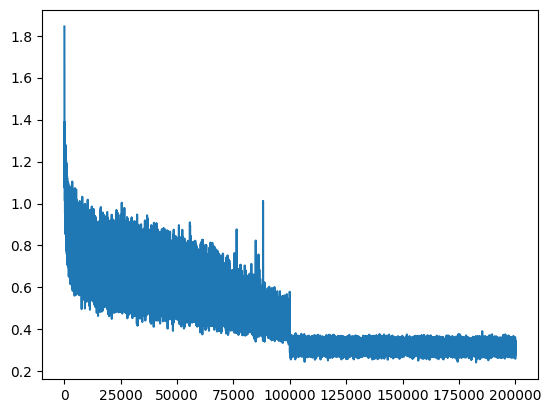

In [324]:
plt.plot(stepsi, lossi)

In [325]:

emb = C[Xtr]
h = torch.tanh(emb.view(-1, INPUT_LAYER_SIZE) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.0747, grad_fn=<NllLossBackward0>)

In [326]:
# training split, dev/validation split, test split
# 80%, 10%, 10%
# training parameters, find hyper-parameters, to test sparsely
emb = C[Xdev]
h = torch.tanh(emb.view(-1, INPUT_LAYER_SIZE) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.1330, grad_fn=<NllLossBackward0>)